In [1]:
import re

regex = re.compile(r"\((\d+), '([^']+)', '([^']+)', (\d+), ('[^']+'\))")

mapper = dict()

with open('n96ncsr5g4-1/index.txt', 'r') as file:
    fields = file.readlines()
    for field in fields:
        match = re.match(regex, field)
        if match:
            mapper[match.group(3)] = match.group(4)

print(len(mapper))

79987


In [2]:
import os 
import tqdm

# https://data.mendeley.com/datasets/n96ncsr5g4/1

files = []

for part in range(1, 7):  # Dataset parts 1 to 6
    dataset_path = f'n96ncsr5g4-1/dataset/dataset-part-{part}'
    for file in os.listdir(dataset_path):
        full_path = f'{dataset_path}/{file}'
        files.append(full_path)

X = []
y = []
max_files = 1000
ben_files_max = 500
phi_files_max = 500

for file in tqdm.tqdm(files[:max_files]):
    # Extract the filename from the full path
    filename = file.split('/')[-1]
    if filename in mapper and phi_files_max > 0:
        X.append(file)
        y.append(int(mapper[filename]))
        phi_files_max -= 1
    if filename in mapper and ben_files_max > 0:
        X.append(file)
        y.append(int(mapper[filename]))
        ben_files_max -= 1

100%|██████████| 1000/1000 [00:00<00:00, 711622.67it/s]


In [3]:
import os
import networkx as nx
from bs4 import BeautifulSoup
from collections import deque

# Function to parse HTML and create a DOM tree
def parse_html(html_content):
    """
    Parses the HTML document and returns a DOM tree using BeautifulSoup.
    """
    soup = BeautifulSoup(html_content, 'html.parser')
    return soup

# Function to build a graph from the DOM tree
def build_graph(dom_tree):
    """
    Builds a graph representation of the HTML DOM tree.
    Uses level-order traversal to create the graph.
    """
    if dom_tree is None:
        return 0  # Return 0 if no nodes exist
    
    graph = nx.DiGraph()  # Initialize an empty directed graph
    
    # Use a queue for level-order traversal of the DOM tree
    queue = deque([dom_tree])
    
    while queue:
        node = queue.popleft()  # Dequeue the current node
        
        if node.name:  # Only consider actual HTML tags (ignore strings and comments)
            # Add the tag name (node.name) as a vertex
            graph.add_node(id(node), tag=node.name)  # Use unique node id for the graph
            
            # Add all the children of the current node
            for child in node.children:
                if child.name:  # Only consider valid HTML tags
                    # Add the child node's tag name as a vertex
                    graph.add_node(id(child), tag=child.name)
                    # Add an edge from parent (node) to child
                    graph.add_edge(id(node), id(child))
                    # Enqueue the child for further processing
                    queue.append(child)
    
    return graph

# Function to process all HTML files in X and build graphs
def process_html_files(X):
    graphs = []
    text = []
    
    for file_path in tqdm.tqdm(X):
        # Check if the file exists
        if not os.path.exists(file_path):
            print(f"File {file_path} does not exist.")
            continue
        
        # Read the HTML content from the file
        with open(file_path, 'r', encoding='utf-8', errors='ignore') as file:
            html_content = file.read()
            text.append(html_content)
        
        # Parse the HTML document into a DOM tree
        dom_tree = parse_html(html_content)
        
        # Build the graph from the DOM tree
        graph = build_graph(dom_tree)
        graphs.append(graph)
    
    return graphs, text

# Process all HTML files and build the corresponding graphs
graphs, text = process_html_files(X)


100%|██████████| 1000/1000 [00:16<00:00, 61.13it/s]


In [4]:
import torch
from torch_geometric.utils import from_networkx
import numpy as np

# HTML tags to one-hot encode
HTML_TAGS = ['html', 'head', 'title', 'body', 'h1', 'p', 'a', 'div', 'span', 'h2', 'h3', 'ul', 'li', 'table', 'tr', 'td', 'meta', 'script']

# Function to one-hot encode the HTML tags
def one_hot_encode_tag(tag, tag_set):
    encoding = np.zeros(len(tag_set))
    if tag in tag_set:
        encoding[tag_set.index(tag)] = 1
    return encoding

# Convert the networkx graph to PyG data format and prepare node features
def convert_to_pyg_graph(graph):
    # Prepare node features (one-hot encoded tags)
    node_features = []
    for node, data in graph.nodes(data=True):
        tag = data['tag']  # Get the tag of the node
        node_features.append(one_hot_encode_tag(tag, HTML_TAGS))  # One-hot encode the tag

    # Convert node features to a tensor
    node_features = torch.tensor(node_features, dtype=torch.float32)

    # Convert networkx graph to a PyTorch Geometric graph
    pyg_graph = from_networkx(graph)

    # Add node features to the PyG graph
    pyg_graph.x = node_features  # PyG expects features to be stored in `x`

    return pyg_graph

# Function to process and convert all graphs in the list
def convert_all_graphs_to_pyg(graphs):
    pyg_graphs = []
    for i, graph in tqdm.tqdm(enumerate(graphs)):
        pyg_graph = convert_to_pyg_graph(graph)  # Convert each networkx graph to PyG format
        pyg_graphs.append(pyg_graph)  # Store the converted PyG graph
    
    return pyg_graphs

# Convert all networkx graphs to PyTorch Geometric graphs
pyg_graphs = convert_all_graphs_to_pyg(graphs)


0it [00:00, ?it/s]/var/folders/lz/54h48fsx6294gn68v0q9pp4m0000gn/T/ipykernel_19985/3874107474.py:24: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:281.)
  node_features = torch.tensor(node_features, dtype=torch.float32)
1000it [00:05, 176.15it/s]


In [5]:
from torch_geometric.nn import SAGEConv
import torch.nn as nn
import torch.nn.functional as F
import torch
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.nn import GATConv
from transformers import BertTokenizer, BertModel

class GraphSAGEModel(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats, dropout=0.5):
        super(GraphSAGEModel, self).__init__()
        self.sage1 = SAGEConv(in_feats, hidden_feats)
        self.sage2 = SAGEConv(hidden_feats, hidden_feats)
        
        self.fc = nn.Linear(hidden_feats, out_feats)
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.sage1(x, edge_index))
        x = F.relu(self.sage2(x, edge_index))
        
        # Pooling
        x = global_mean_pool(x, batch)
        x = self.dropout(x)
        x = self.fc(x)
        return F.log_softmax(x, dim=1)

In [6]:
import torch
from torch_geometric.data import Batch
from torch.utils.data import Dataset
from torch_geometric.loader import DataLoader

# Define a standard Dataset for handling graphs and labels
class GraphDataset(Dataset):
    def __init__(self, graphs, labels):
        self.graphs = graphs  # List of PyG graphs
        self.labels = labels   # List of labels (graph-level)

    def __len__(self):
        return len(self.graphs)  # Number of graphs in the dataset

    def __getitem__(self, idx):
        return self.graphs[idx], self.labels[idx]  # Return graph and corresponding label

# Custom collate function to handle batching of graphs and labels
def collate_fn(batch):
    graphs, labels = zip(*batch)  # Unzips the batch into two tuples: graphs and labels
    graphs = Batch.from_data_list(graphs)  # Use PyG Batch to create a batch of graphs
    labels = torch.tensor(labels)  # Convert labels to a tensor
    return graphs, labels

# Create the dataset
graph_dataset = GraphDataset(pyg_graphs, y)

# Create the DataLoader to load graphs and labels in batches, with the custom collate function
loader = DataLoader(graph_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)

In [7]:
from torch.optim import Adam
import torch.nn as nn

in_feats = len(HTML_TAGS)  # Number of input features (one-hot encoded tags)
hidden_feats = 128  # Number of hidden units (adjustable)
out_feats = 2  # Number of output classes (e.g., phishing or benign)
dropout = 0.5
gcn_model = GraphSAGEModel(in_feats, hidden_feats, out_feats)

# Loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(gcn_model.parameters(), lr=0.01)

# Training loop
def train_model(model, loader, epochs=100):
    model.train()  # Set the model to training mode
    for epoch in range(epochs):
        epoch_loss = 0
        for batch_data, batch_labels in loader:  # Now batch_data includes both graphs and labels
            optimizer.zero_grad()  # Zero gradients from previous step
            
            # Forward pass
            out = model(batch_data)  # Pass the batch of graphs to the model
            
            # Compute loss (cross-entropy loss between predictions and labels)
            loss = loss_fn(out, batch_labels)
            
            # Backpropagation
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        # Print loss at intervals
        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {epoch_loss/len(loader)}")

# Train the model
train_model(gcn_model, loader, epochs=100)

Epoch 0, Loss: 0.5661952023357153
Epoch 10, Loss: 0.37203842304903084
Epoch 20, Loss: 0.33944159628130727
Epoch 30, Loss: 0.292342239170328
Epoch 40, Loss: 0.287241859628847
Epoch 50, Loss: 0.26450027936154585
Epoch 60, Loss: 0.2526507948297367
Epoch 70, Loss: 0.22357963751276452
Epoch 80, Loss: 0.24723352049384267
Epoch 90, Loss: 0.21589720412455357


In [8]:
# https://www.kaggle.com/datasets/huntingdata11/phishing-website-html-classification?resource=download

Xtestraw = []
ytestraw = []
for phase in ['training', 'validation']:
    for label in ['NotPhish', 'Phish']:
        dirpath = os.path.join('archive', phase, label)
        for file in tqdm.tqdm(os.listdir(dirpath)):
            Xtestraw.append(os.path.join(dirpath, file))
            ytestraw.append(0 if label == 'NotPhish' else 1)

100%|██████████| 1055/1055 [00:00<00:00, 1174984.26it/s]


In [9]:
Xtest = Xtestraw[:500]
Xtest.extend(Xtestraw[7000:7500])

ytest = ytestraw[:500]
ytest.extend(ytestraw[7000:7500])

In [10]:
test_graphs, test_html_text = process_html_files(Xtest)
test_pyg_graphs = convert_all_graphs_to_pyg(test_graphs)

100%|██████████| 1000/1000 [00:48<00:00, 20.77it/s]
1000it [00:10, 97.18it/s]


In [11]:
# Create the dataset
test_graph_dataset = GraphDataset(test_pyg_graphs, ytest)

# Create the DataLoader to load graphs and labels in batches, with the custom collate function
test_loader = DataLoader(test_graph_dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)

Accuracy: 0.6740
Precision: 0.7500
Recall: 0.5220
F1-Score: 0.6156


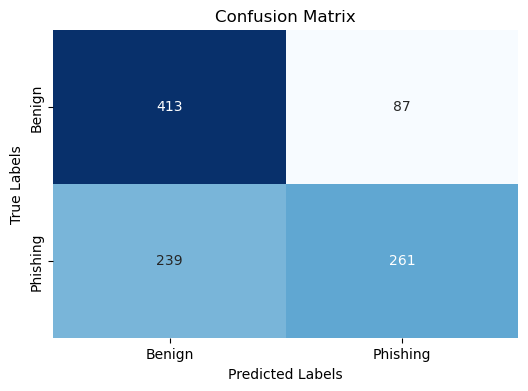

(0.674, 0.75, 0.522, 0.6155660377358491)

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import numpy as np

# Function to evaluate the model and plot confusion matrix
def evaluate_model(model, loader):
    model.eval()  # Set the model to evaluation mode
    all_preds = []
    all_labels = []
    
    with torch.no_grad():  # Disable gradient computation for testing
        for batch_data, batch_labels in loader:  # Iterate over the test loader
            # Forward pass
            out = model(batch_data)  # Get model predictions
            
            # Get the predicted class (highest logit)
            preds = out.argmax(dim=1)  # Shape: (batch_size,)
            
            # Store predictions and true labels
            all_preds.append(preds.cpu().numpy())  # Move to CPU and convert to numpy
            all_labels.append(batch_labels.cpu().numpy())  # Move to CPU and convert to numpy

    # Flatten the lists of predictions and labels
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='binary')
    recall = recall_score(all_labels, all_preds, average='binary')
    f1 = f1_score(all_labels, all_preds, average='binary')
    
    # Print the metrics
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    
    # Confusion Matrix
    conf_matrix = confusion_matrix(all_labels, all_preds)
    
    # Plot Confusion Matrix using Seaborn
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, 
                xticklabels=['Benign', 'Phishing'], yticklabels=['Benign', 'Phishing'])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()
    
    return accuracy, precision, recall, f1

# Assuming `loader` is your test DataLoader
evaluate_model(gcn_model, test_loader)